In [1]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120275 sha256=c81c3544eb995d3f86120fb5dfdceeca9a20201c2fafddce7b5de8799017a149
  Stored in directory: /root/.cache/pip/wheels/83/97/6b/e9e0cde099cc40f972b8dd23367308f7705ae06cd6d4714658
Successfully built japanize-matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

In [3]:
# レース結果データ読み込み
# Loading race results data
race_result_df = pd.read_csv('../input/jra-horse-racing-dataset/19860105-20210731_race_result.csv', low_memory=False)
print(race_result_df.shape)
race_result_df.head()

(1626811, 66)


,レース馬番ID,レースID,レース日付,開催回数,競馬場コード,競馬場名,開催日数,競争条件,レース記号/[抽],レース記号/(馬齢),...,4コーナー,上り,単勝,人気,馬体重,場体重増減,東西・外国・地方区分,調教師,馬主,賞金(万円)
0,19860101010102,198601010101,1986-06-07,1,1,札幌,1,4歳以上300万下,[抽],(馬齢),...,1.0,38.6,2.1,1.0,468.0,0.0,東,宮沢今朝,アイ・ケイ・テイ・オーナーズ,290.0
1,19860101010103,198601010101,1986-06-07,1,1,札幌,1,4歳以上300万下,[抽],(馬齢),...,4.0,40.3,7.0,4.0,430.0,4.0,東,斎藤籌敬,松井健一,120.0
2,19860101010105,198601010101,1986-06-07,1,1,札幌,1,4歳以上300万下,[抽],(馬齢),...,3.0,40.6,59.1,6.0,460.0,-4.0,西,境直行,塚原金治,73.0
3,19860101010106,198601010101,1986-06-07,1,1,札幌,1,4歳以上300万下,[抽],(馬齢),...,2.0,41.2,2.1,2.0,456.0,14.0,西,坂口正大,鈴木隆,44.0
4,19860101010107,198601010101,1986-06-07,1,1,札幌,1,4歳以上300万下,[抽],(馬齢),...,4.0,41.7,6.2,3.0,432.0,-6.0,西,荻野光男,勢戸澄雄,29.0


In [4]:
race_result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1626811 entries, 0 to 1626810
Data columns (total 66 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   レース馬番ID      1626811 non-null  int64  
 1   レースID        1626811 non-null  int64  
 2   レース日付        1626811 non-null  object 
 3   開催回数         1626811 non-null  int64  
 4   競馬場コード       1626811 non-null  int64  
 5   競馬場名         1626811 non-null  object 
 6   開催日数         1626811 non-null  int64  
 7   競争条件         1626811 non-null  object 
 8   レース記号/[抽]    12834 non-null    object 
 9   レース記号/(馬齢)   827790 non-null   object 
 10  レース記号/牝      208613 non-null   object 
 11  レース記号/(父)    23423 non-null    object 
 12  レース記号/(別定)   361406 non-null   object 
 13  レース記号/(混)    753618 non-null   object 
 14  レース記号/(ハンデ)  95331 non-null    object 
 15  レース記号/(抽)    6016 non-null     object 
 16  レース記号/(市)    6180 non-null     object 
 17  レース記号/(定量)   324044 non-null   object 
 18  レー

In [5]:
# 距離別データ件数
# Number of data by distance
kyori = race_result_df['距離(m)'].value_counts()
kyori.head(20)

1200    360914
1800    335132
1400    194003
1600    179386
1700    147138
2000    146588
1000     88707
2200     25552
2400     25367
2500     12863
3000     12797
2600     10653
2100     10018
1300      9321
1150      8660
1500      5968
1900      5498
2910      4316
2300      3888
2880      3262
Name: 距離(m), dtype: int64

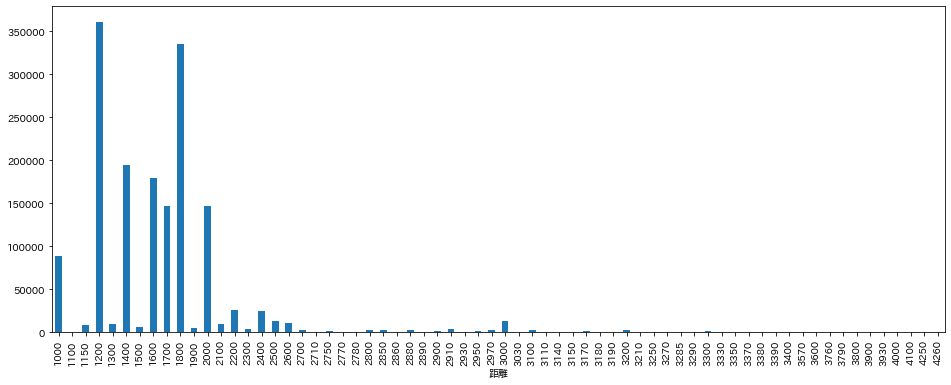

In [6]:
kyori.sort_index().plot(kind='bar', figsize=(16, 6))
plt.xlabel('距離');

In [7]:
# タイム変換用関数
# Functions for time conversion
def time_convert(value):
    if isinstance(value, str):
        m1 = int(value[0])
        s1 = float(value[2:])
        return m1 * 60 + s1
    else:
        return value

In [8]:
# タイム変換
# Time conversion
race_result_df['race_time'] = race_result_df['タイム'].map(time_convert)
race_result_df[['タイム', 'race_time']].head()

,タイム,race_time
0,1:34.3,94.3
1,1:36.0,96.0
2,1:36.2,96.2
3,1:36.6,96.6
4,1:37.4,97.4


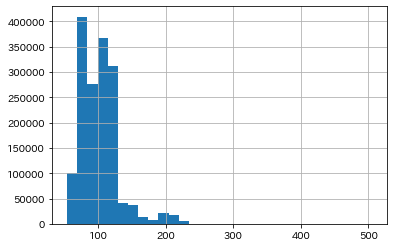

In [9]:
# レースタイムのヒストグラム
# Histogram of race times
race_result_df['race_time'].hist(bins=30);

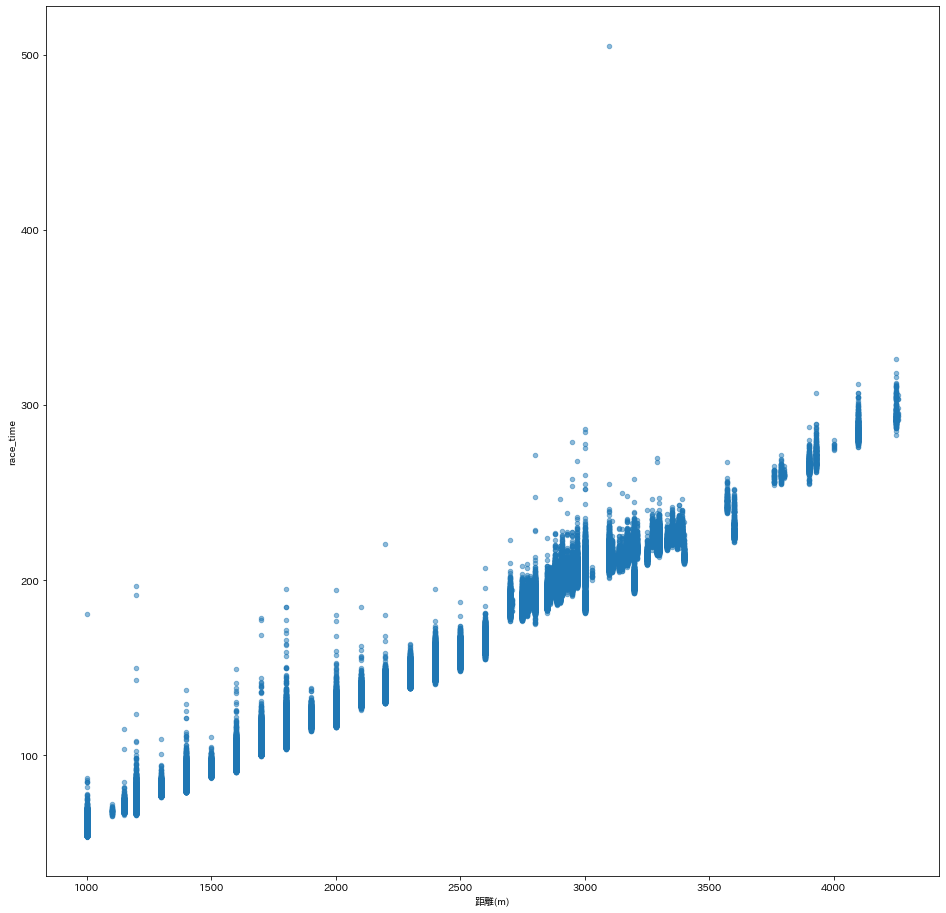

In [10]:
# レースタイムと距離の散布図
# Scatterplot of race times and distances
race_result_df.plot(kind='scatter', x='距離(m)', y='race_time', figsize=(16, 16), alpha=0.5);

In [11]:
# 距離が 1200m のデータを抽出
# Extract data for distance 1200m
race_1200 = race_result_df[race_result_df['距離(m)']==1200]
print(race_1200.shape)
race_1200.head(2)

(360914, 67)


,レース馬番ID,レースID,レース日付,開催回数,競馬場コード,競馬場名,開催日数,競争条件,レース記号/[抽],レース記号/(馬齢),...,上り,単勝,人気,馬体重,場体重増減,東西・外国・地方区分,調教師,馬主,賞金(万円),race_time
13,19860101010301,198601010103,1986-06-07,1,1,札幌,1,4歳未勝利,NaN,(馬齢),...,37.0,2.0,1.0,502.0,-2.0,東,尾形盛次,大和商事,390.0,72.7
14,19860101010308,198601010103,1986-06-07,1,1,札幌,1,4歳未勝利,NaN,(馬齢),...,38.2,27.3,7.0,448.0,0.0,西,福永甲,辻牧場,160.0,74.0


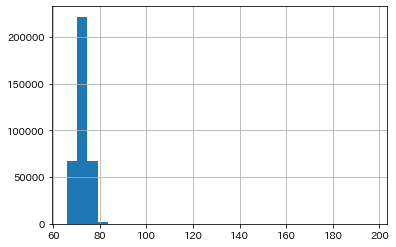

In [12]:
# レースタイムのヒストグラム (外れ値が含まれていると思われる)
# Histogram of race times (It is likely to contain outliers.)
race_1200['race_time'].hist(bins=30);

In [13]:
# レースタイムの基本統計量
# Basic statistics of race times
race_1200['race_time'].describe()

count    358419.000000
mean         72.638398
std           2.410113
min          66.000000
25%          70.800000
50%          72.500000
75%          74.300000
max         196.600000
Name: race_time, dtype: float64

In [14]:
# レースタイムの下位30件を確認
# Check the bottom 30 of race times
race_1200['race_time'].sort_values(ascending=False).head(30)

1052400    196.6
794499     191.7
132568     149.7
1248134    142.8
881100     123.5
426532     108.0
1513603    107.6
668540     102.3
1265935    100.2
151066      98.8
1097100     98.7
637067      98.4
1176655     97.9
1442038     97.2
930449      95.6
1427960     95.3
730829      95.0
1226019     94.7
687564      94.5
442189      93.0
1359969     92.8
368036      92.8
1135109     92.4
1132039     92.1
793608      91.9
687823      91.9
313022      91.6
1474855     91.5
1078994     90.9
253162      90.2
Name: race_time, dtype: float64

In [15]:
# レースタイムの99.9%点の値を確認
# Check the value of the 99.9% point of race time
race_1200['race_time'].quantile(0.999)

81.7

In [16]:
# 99.9%点以下のデータを抽出
# Extract data below the 99.9% point
race_time_1200_999 = race_1200[race_1200['race_time'] <= race_1200['race_time'].quantile(0.999)]
print(race_time_1200_999.shape)
race_time_1200_999.head(2)

(358065, 67)


,レース馬番ID,レースID,レース日付,開催回数,競馬場コード,競馬場名,開催日数,競争条件,レース記号/[抽],レース記号/(馬齢),...,上り,単勝,人気,馬体重,場体重増減,東西・外国・地方区分,調教師,馬主,賞金(万円),race_time
13,19860101010301,198601010103,1986-06-07,1,1,札幌,1,4歳未勝利,NaN,(馬齢),...,37.0,2.0,1.0,502.0,-2.0,東,尾形盛次,大和商事,390.0,72.7
14,19860101010308,198601010103,1986-06-07,1,1,札幌,1,4歳未勝利,NaN,(馬齢),...,38.2,27.3,7.0,448.0,0.0,西,福永甲,辻牧場,160.0,74.0


count    358065.000000
mean         72.625222
std           2.352244
min          66.000000
25%          70.800000
50%          72.500000
75%          74.300000
max          81.700000
Name: race_time, dtype: float64


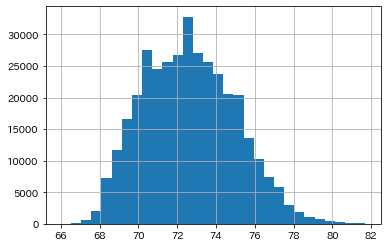

In [17]:
# レースタイムの基本統計量とヒストグラム
# Basic statistics and histogram of race times
print(race_time_1200_999['race_time'].describe())
race_time_1200_999['race_time'].hist(bins=30);

In [18]:
# 競馬場ごとのデータ件数
# Number of data per racecourse
race_time_1200_999['競馬場名'].value_counts().sort_values(ascending=False)

中山    83964
京都    49589
阪神    47989
小倉    38990
新潟    35838
福島    30294
中京    27909
函館    17268
札幌    13506
東京    12718
Name: 競馬場名, dtype: int64

In [19]:
# 競馬場ごとのレースタイムの中央値
# Median race time per racecourse
race_time_median_order = race_time_1200_999.groupby('競馬場名')['race_time'].median().sort_values()
race_time_median_order

競馬場名
小倉    70.6
中京    71.1
福島    71.2
函館    71.4
札幌    71.4
新潟    73.0
京都    73.3
中山    73.4
阪神    73.8
東京    74.7
Name: race_time, dtype: float64

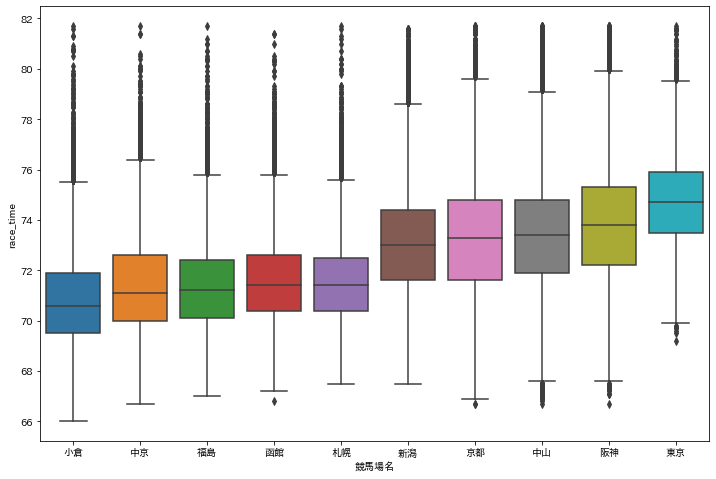

In [20]:
# 競馬場ごとのレースタイムの箱ひげ図
# Boxplot of race times per racecourse
plt.figure(figsize=(12, 8))
sns.boxplot(x='競馬場名', y='race_time', data=race_time_1200_999, order=race_time_median_order.index);

In [21]:
# データ件数が一番多い、中山競馬場のデータを抽出
# Extract data from Nakayama racecourse, which has the largest number of data.
nakayama_1200_999 = race_time_1200_999[race_time_1200_999['競馬場名']=='中山']
print(nakayama_1200_999.shape)
nakayama_1200_999.head(2)

(83964, 67)


,レース馬番ID,レースID,レース日付,開催回数,競馬場コード,競馬場名,開催日数,競争条件,レース記号/[抽],レース記号/(馬齢),...,上り,単勝,人気,馬体重,場体重増減,東西・外国・地方区分,調教師,馬主,賞金(万円),race_time
13535,19860601010306,198606010103,1986-01-05,1,6,中山,1,4歳新馬,NaN,(馬齢),...,38.4,57.9,14.0,480.0,0.0,東,保田隆芳,西山正行,480.0,72.8
13536,19860601010301,198606010103,1986-01-05,1,6,中山,1,4歳新馬,NaN,(馬齢),...,38.1,2.8,1.0,416.0,0.0,東,相川勝敏,中村勝五郎,190.0,72.8


count    83964.000000
mean        73.290357
std          2.250102
min         66.700000
25%         71.900000
50%         73.400000
75%         74.800000
max         81.700000
Name: race_time, dtype: float64


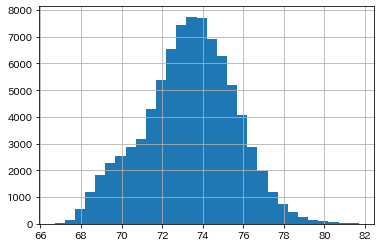

In [22]:
# レースタイムの基本統計量とヒストグラム
# Basic statistics and histogram of race times
print(nakayama_1200_999['race_time'].describe())
nakayama_1200_999['race_time'].hist(bins=30);

In [23]:
# 天候ごとのデータ件数と中央値
# Number and median data per weather
print(nakayama_1200_999['天候'].value_counts())
nakayama_race_time_median_order = nakayama_1200_999.groupby('天候')['race_time'].median().sort_values()
print(nakayama_race_time_median_order)

晴     52434
曇     23976
雨      4734
小雨     2669
雪       106
小雪       45
Name: 天候, dtype: int64
天候
小雪    72.3
曇     73.2
小雨    73.3
雨     73.3
晴     73.5
雪     73.6
Name: race_time, dtype: float64


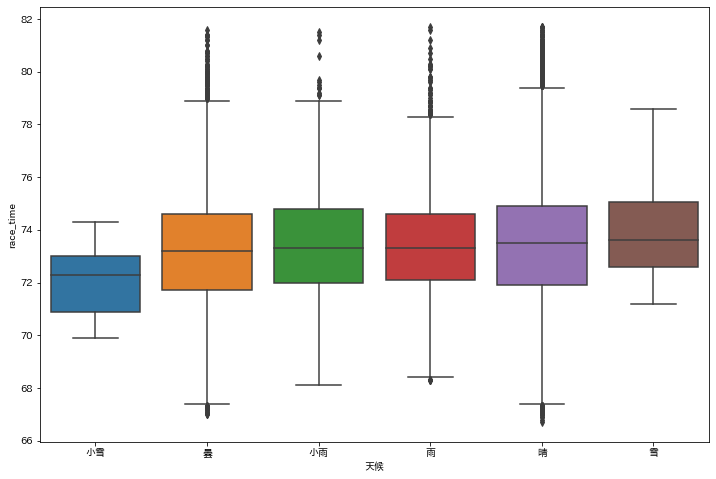

In [24]:
# 天候ごとの箱ひげ図 (小雪と雪はデータ件数が少ないので当てにならない)
# Boxplot per weather (Light snow and snow are not reliable because of the small number of data.)
plt.figure(figsize=(12, 8))
sns.boxplot(x='天候', y='race_time', data=nakayama_1200_999, order=nakayama_race_time_median_order.index);

In [25]:
# 馬場状態ごとのデータ件数と中央値
# Number and median data per track condition
print(nakayama_1200_999['馬場状態1'].value_counts())
nakayama_baba_median_order = nakayama_1200_999.groupby('馬場状態1')['race_time'].median().sort_values()
print(nakayama_baba_median_order)

良     56117
稍重    13717
重      7775
不良     6355
Name: 馬場状態1, dtype: int64
馬場状態1
重     73.1
稍重    73.4
良     73.4
不良    73.5
Name: race_time, dtype: float64


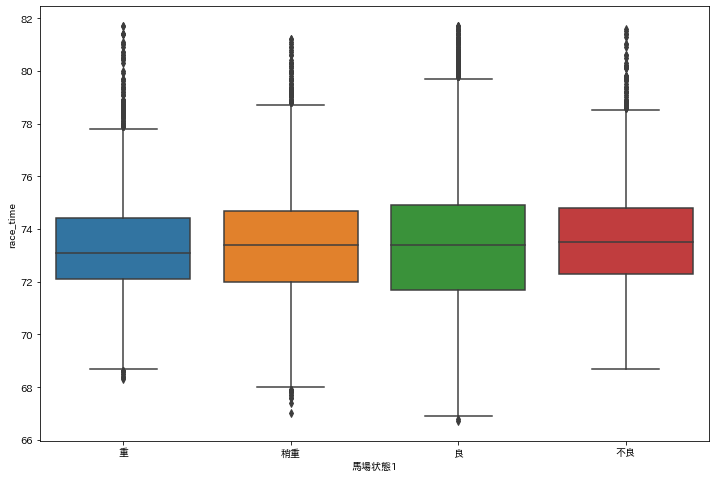

In [26]:
# 馬場状態ごとの箱ひげ図 (思ったより差が少ない)
# Boxplot per track condition (Difference is less than expected)
plt.figure(figsize=(12, 8))
sns.boxplot(x='馬場状態1', y='race_time', data=nakayama_1200_999, order=nakayama_baba_median_order.index);

In [27]:
# 芝・ダート別のデータ件数と中央値
# Number and median data by turf and dirt
print(nakayama_1200_999['芝・ダート区分'].value_counts())
nakayama_shiba_median_order = nakayama_1200_999.groupby('芝・ダート区分')['race_time'].median().sort_values()
print(nakayama_shiba_median_order)

ダート    65677
芝      18287
Name: 芝・ダート区分, dtype: int64
芝・ダート区分
芝      70.3
ダート    73.9
Name: race_time, dtype: float64


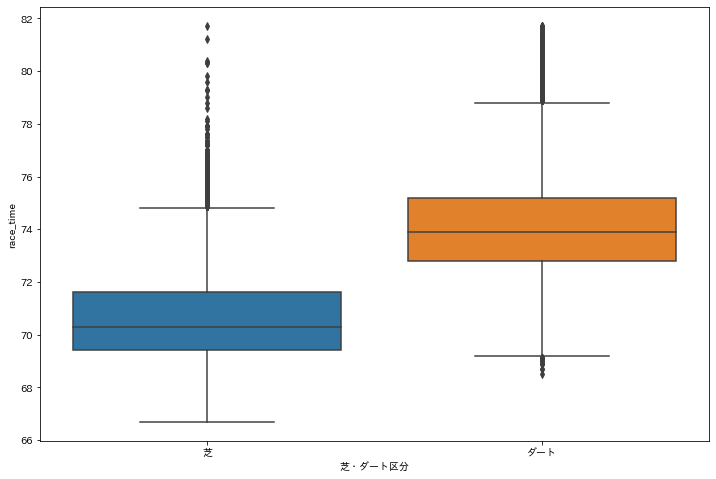

In [28]:
# 芝・ダート別の箱ひげ図
# Boxplot by turf and dirt
plt.figure(figsize=(12, 8))
sns.boxplot(x='芝・ダート区分', y='race_time', data=nakayama_1200_999, order=nakayama_shiba_median_order.index);

In [29]:
# 芝のデータを抽出
# Extract data of turf
nakayama_shiba_1200_999 = nakayama_1200_999[nakayama_1200_999['芝・ダート区分']=='芝']
print(nakayama_shiba_1200_999.shape)
nakayama_shiba_1200_999.head(2)

(18287, 67)


,レース馬番ID,レースID,レース日付,開催回数,競馬場コード,競馬場名,開催日数,競争条件,レース記号/[抽],レース記号/(馬齢),...,上り,単勝,人気,馬体重,場体重増減,東西・外国・地方区分,調教師,馬主,賞金(万円),race_time
13625,19860601010902,198606010109,1986-01-05,1,6,中山,1,4歳オープン,NaN,NaN,...,36.5,21.7,8.0,430.0,2.0,東,栗田博憲,中央牧場,1200.0,70.7
13626,19860601010903,198606010109,1986-01-05,1,6,中山,1,4歳オープン,NaN,NaN,...,36.2,11.2,5.0,410.0,-6.0,東,栗田博憲,新冠キタノ牧場,480.0,70.7


In [30]:
# 馬場状態ごとのデータ件数と中央値
# Number and median data per track condition
print(nakayama_shiba_1200_999['馬場状態1'].value_counts())
nakayama_shiba_baba_median_order = nakayama_shiba_1200_999.groupby('馬場状態1')['race_time'].median().sort_values()
print(nakayama_shiba_baba_median_order)

良     14205
稍重     2431
重      1002
不良      649
Name: 馬場状態1, dtype: int64
馬場状態1
良     70.1
稍重    70.7
重     71.8
不良    73.3
Name: race_time, dtype: float64


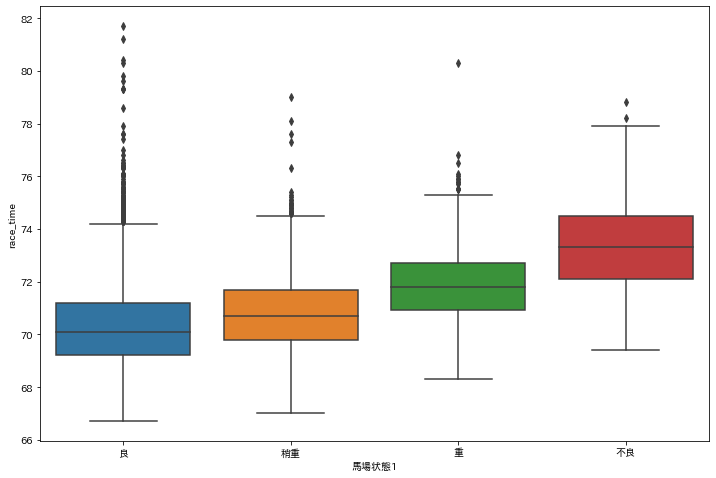

In [31]:
# 馬場状態ごとの箱ひげ図 (はっきりとした傾向が現れた)
# Boxplot per track condition (A clear trend emerged.)
plt.figure(figsize=(12, 8))
sns.boxplot(x='馬場状態1', y='race_time', data=nakayama_shiba_1200_999, order=nakayama_shiba_baba_median_order.index);

In [32]:
# ダートのデータを抽出
# Extract data of dirt
nakayama_dirt_1200_999 = nakayama_1200_999[nakayama_1200_999['芝・ダート区分']=='ダート']
print(nakayama_dirt_1200_999.shape)
nakayama_dirt_1200_999.head(2)

(65677, 67)


,レース馬番ID,レースID,レース日付,開催回数,競馬場コード,競馬場名,開催日数,競争条件,レース記号/[抽],レース記号/(馬齢),...,上り,単勝,人気,馬体重,場体重増減,東西・外国・地方区分,調教師,馬主,賞金(万円),race_time
13535,19860601010306,198606010103,1986-01-05,1,6,中山,1,4歳新馬,NaN,(馬齢),...,38.4,57.9,14.0,480.0,0.0,東,保田隆芳,西山正行,480.0,72.8
13536,19860601010301,198606010103,1986-01-05,1,6,中山,1,4歳新馬,NaN,(馬齢),...,38.1,2.8,1.0,416.0,0.0,東,相川勝敏,中村勝五郎,190.0,72.8


In [33]:
# 馬場状態ごとのデータ件数と中央値
# Number and median data per track condition
print(nakayama_dirt_1200_999['馬場状態1'].value_counts())
nakayama_dirt_baba_median_order = nakayama_dirt_1200_999.groupby('馬場状態1')['race_time'].median().sort_values()
print(nakayama_dirt_baba_median_order)

良     41912
稍重    11286
重      6773
不良     5706
Name: 馬場状態1, dtype: int64
馬場状態1
重     73.4
不良    73.5
稍重    73.8
良     74.1
Name: race_time, dtype: float64


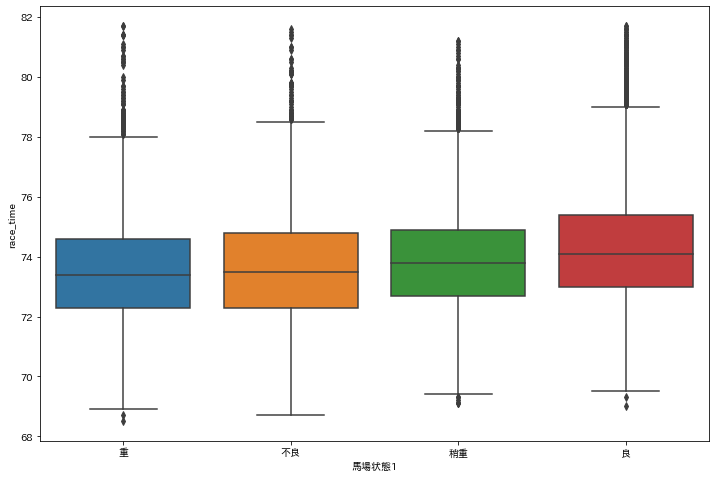

In [34]:
# 馬場状態ごとの箱ひげ図 (芝の場合とはほぼ逆の傾向になっている)
# Boxplot per track condition (The trend is almost the opposite of that for turf.)
plt.figure(figsize=(12, 8))
sns.boxplot(x='馬場状態1', y='race_time', data=nakayama_dirt_1200_999, order=nakayama_dirt_baba_median_order.index);